In [1]:
import common_functions

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-06-29.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-06-29.nc")
control_ds_dust_sites = xr.open_dataset("DATA/processed/5_control_grid_dust_sites_2026-06-22.nc")

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

## Surface categories

In [3]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
soil_order_dict = common_functions.get_soil_order_names_major()
soil_order_colors = common_functions.get_soil_order_colors_major()

In [4]:
#--- Using the normalized frequency of how often wind speeds exceed 10 m/s

domain_size = len(control_ds['lat']) * len(control_ds['lon'])
domain_freq = (control_ds['wind_speed'] >= 10).sum().item()
domain_winds_per_pixel = domain_freq / domain_size

def wind_freq_by_category(ds, category_dict, category_name):
    categories = list(category_dict.keys())

    wind_freqs = []

    for k in categories:
        filtered_ds = ds.where(ds[category_name] == k)
        category_size = filtered_ds['soil_texture'].count(dim=['lat', 'lon']).item()
        category_freq = (filtered_ds['wind_speed'] >= 10).sum().item()
        category_winds_per_pixel = (category_freq / category_size if category_size != 0 else np.nan)
        category_winds_per_pixel_normalized = category_winds_per_pixel / domain_winds_per_pixel

        # print(f"{category_dict[k]}: {wind_freq_category:.2f}")
        # print(f"{category_dict[k]}: {category_freq}/{category_size} = {category_winds_per_pixel:.2f}/{domain_winds_per_pixel:.2f} = {category_winds_per_pixel_normalized:.2f}")
        wind_freqs.append(category_winds_per_pixel_normalized)

    return wind_freqs

wind_freqs = wind_freq_by_category(ds=control_ds, category_dict=texture_dict, category_name='soil_texture')

In [5]:
categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]

non_dust_counts = [np.sum(control_ds["soil_texture"] == k).values for k in texture_dict.keys()]
non_dust_total = sum(non_dust_counts)
non_dust_fraction = np.array([count / non_dust_total for count in non_dust_counts])

dust_counts = [np.sum(dust_df["texture"] == k) for k in texture_dict.keys()]
dust_total = sum(dust_counts)
dust_fraction = np.array([count / dust_total for count in dust_counts])

dust_representation = dust_fraction/non_dust_fraction

texture_df = pd.DataFrame({
    "Surface Category": labels,
    "Domain Frequency": np.round(non_dust_fraction,4),
    "Dust Frequency": np.round(dust_fraction, 4), 
    "Dust Representation": np.round(dust_representation, 2),
    "Relative Wind Exposure": np.round(wind_freqs, 2)
})

print(texture_df)

   Surface Category  Domain Frequency  Dust Frequency  Dust Representation  \
0              Sand            0.0609          0.1178                 1.93   
1        Loamy Sand            0.0177          0.0252                 1.42   
2        Sandy Loam            0.2801          0.2404                 0.86   
3         Silt Loam            0.0646          0.0447                 0.69   
4              Silt            0.0000          0.0000                  NaN   
5              Loam            0.4250          0.2888                 0.68   
6   Sandy Clay Loam            0.0461          0.1212                 2.63   
7   Silty Clay Loam            0.0206          0.0189                 0.92   
8         Clay Loam            0.0362          0.0221                 0.61   
9        Sandy Clay            0.0013          0.0000                 0.00   
10       Silty Clay            0.0065          0.0819                12.59   
11             Clay            0.0198          0.0350           

/tmp/ipykernel_4095579/989137617.py:12: RuntimeWarning: invalid value encountered in divide
  dust_representation = dust_fraction/non_dust_fraction


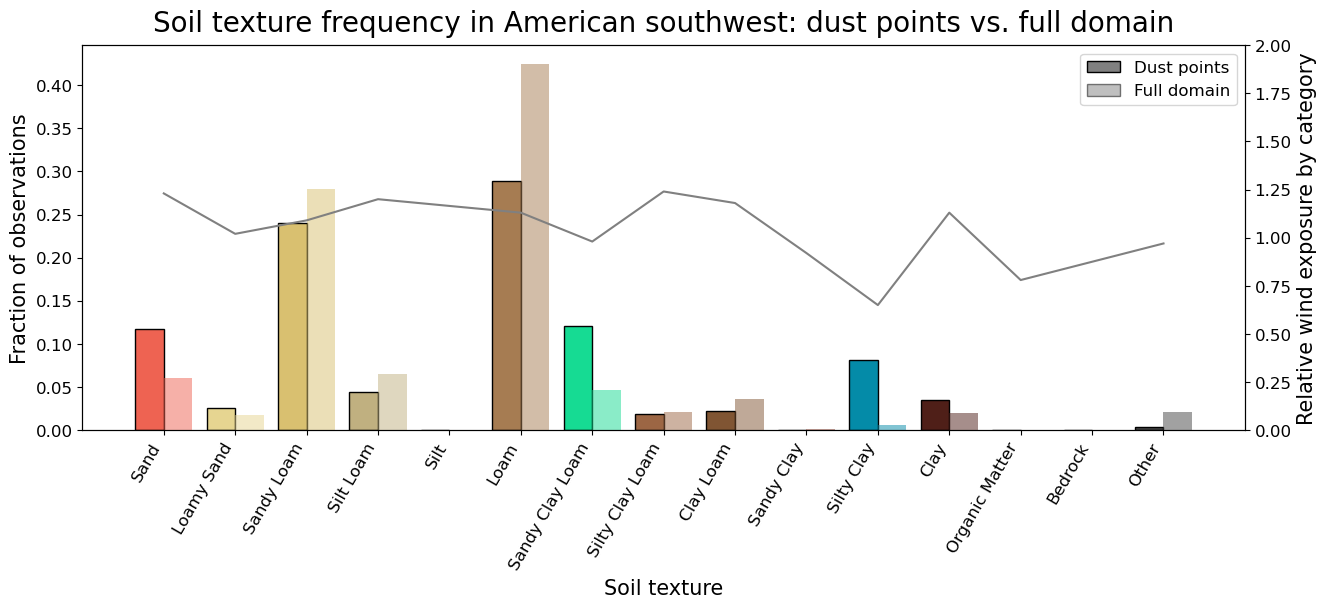

In [6]:
x = np.arange(len(texture_df))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))

for i in x:
    color = texture_colors[i]
    ax.bar(i - width / 2, texture_df['Dust Frequency'][i], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(i + width / 2, texture_df['Domain Frequency'][i], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")


ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = texture_df['Relative Wind Exposure'].interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(0,2)
ax2.set_ylabel("Relative wind exposure by category", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [7]:
#--- Manually setting order of categories
chosen_categories = [7, 15, 8, 16, 9, 10, 14, 17, 1, 18, 5, 3, 6, 19]
labels = [land_cover_dict[k] for k in chosen_categories]
chosen_land_cover_dict = dict(zip(chosen_categories, labels))

mean_wind_by_category = wind_average_by_category(ds=control_ds, category_dict=chosen_land_cover_dict, category_name='usage')

NameError: name 'wind_average_by_category' is not defined

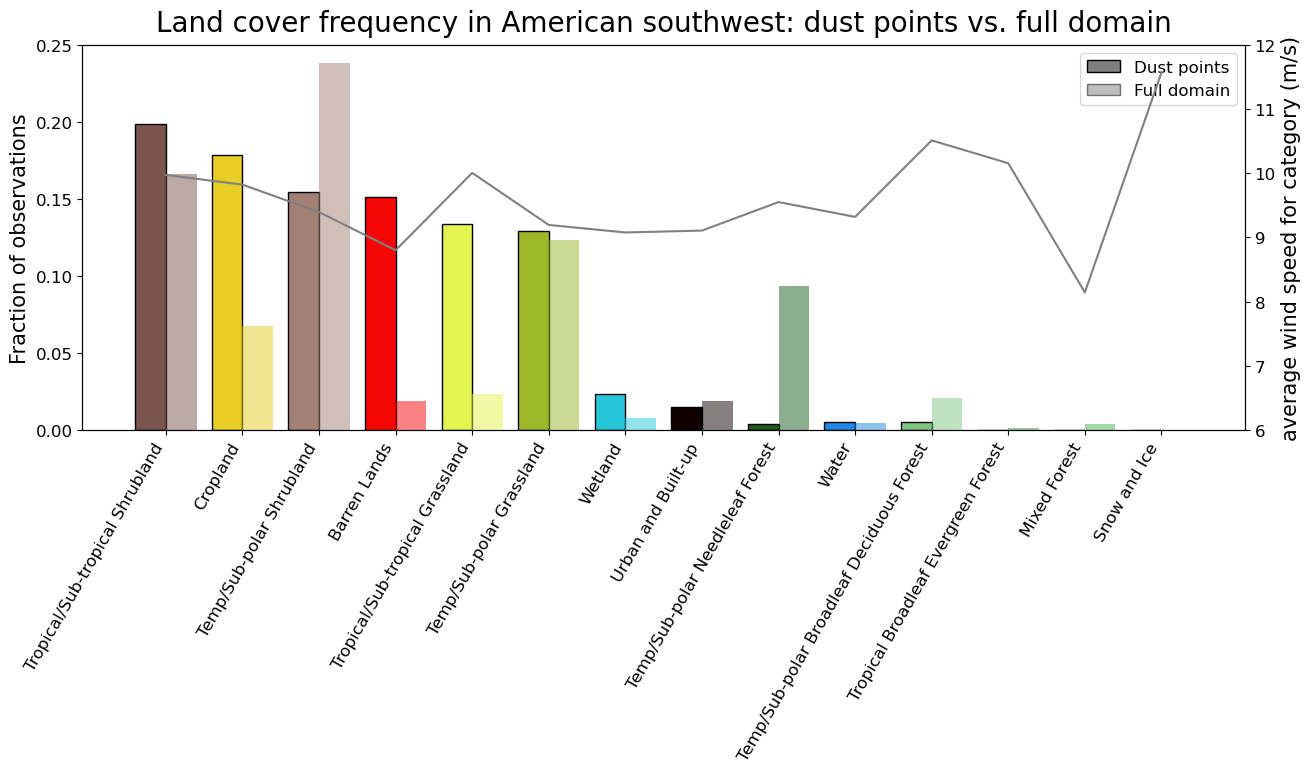

In [ ]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['usage'] == k) for k in land_cover_dict.keys()}
dust_total = len(dust_df)
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['usage'] == k) for k in land_cover_dict.keys()}
non_dust_total = control_ds['usage'].count()
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

#--- Manually set list of categories earlier
x = np.arange(len(chosen_categories))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))

for i, k in enumerate(chosen_categories):
    color = land_cover_colors[k]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

ax.tick_params(labelsize=12)
labels = [land_cover_dict[k] for k in chosen_categories]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
# ax.set_xlabel("Land cover", fontsize=15)
ax.set_title(f"Land cover frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = pd.Series(mean_wind_by_category).interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(6,12)
ax2.set_ylabel("average wind speed for category (m/s)", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/5_land_cover_cec_2_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [9]:
#--- Manually setting order of categories
chosen_categories = [2, 3, 7, 0, 15, 14, 13, 4, 5, 11, 10, 6]
labels = [soil_order_dict[k] for k in chosen_categories]
chosen_soil_order_dict = dict(zip(chosen_categories, labels))

mean_wind_by_category = wind_average_by_category(ds=control_ds, category_dict=chosen_soil_order_dict, category_name='soil_order')

Aridisols: 10.11 m/s
Entisols: 10.12 m/s
Mollisols: 10.84 m/s
Alfisols: 10.38 m/s
Water: 8.84 m/s
Shifting Sands: 9.87 m/s
Salt flats: 8.24 m/s
Gelisols: 12.30 m/s
Histosols: nan m/s
Vertisols: 9.29 m/s
Ultisols: 10.42 m/s
Inceptisols: 10.11 m/s


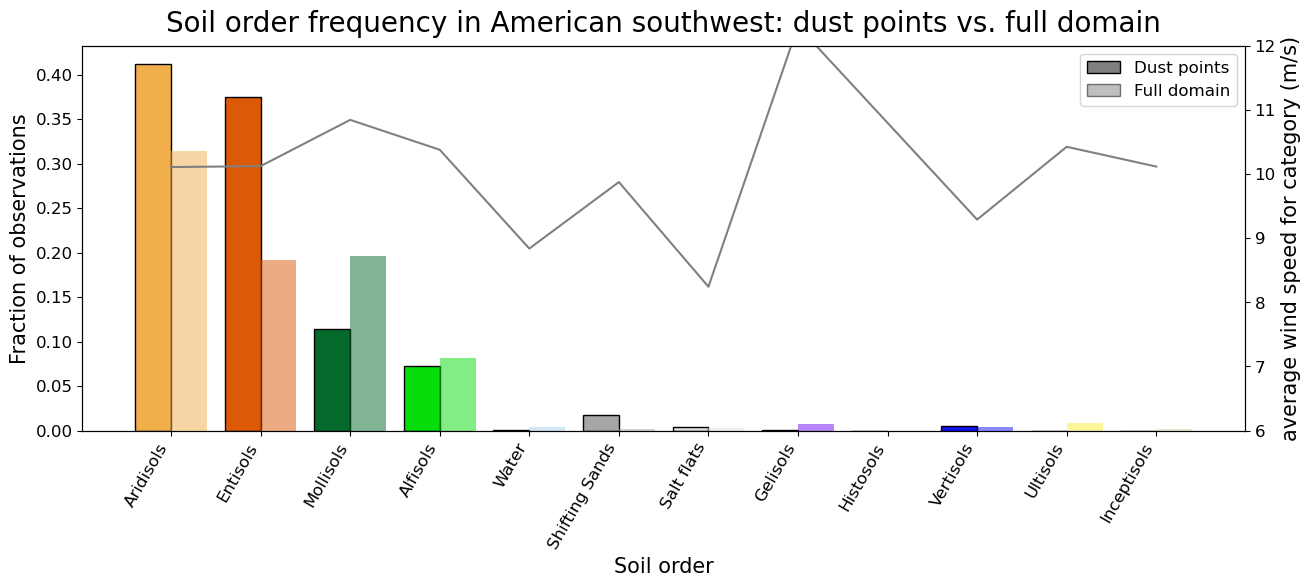

In [16]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['soil_order'] == k) for k in chosen_categories}
dust_total = len(dust_df)
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['soil_order'] == k) for k in chosen_categories}
non_dust_total = control_ds['soil_order'].count()
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

x = np.arange(len(chosen_categories))
labels = [soil_order_dict[k] for k in chosen_categories]
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))
for i, k in enumerate(chosen_categories):
    color = soil_order_colors[k]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

ax.tick_params(labelsize=12)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil order", fontsize=15)
ax.set_title(f"Soil order frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = pd.Series(mean_wind_by_category).interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(6,12)
ax2.set_ylabel("average wind speed for category (m/s)", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/4_soil_types_usda_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [17]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

## Continuous (wind and moisture)

Plotting wind speed bar chart...


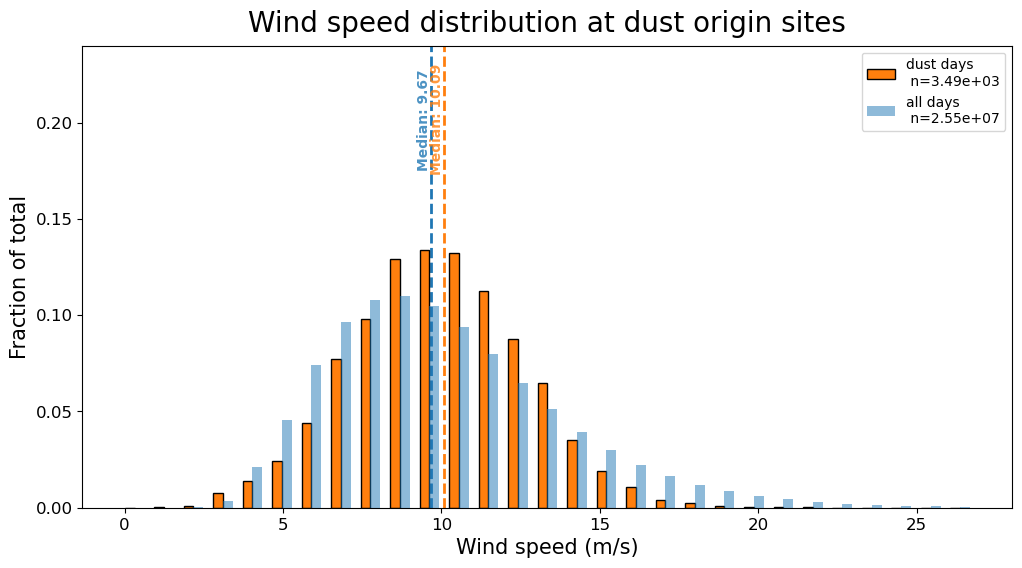

In [18]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust_days, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds_dust_sites["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds_dust_sites["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


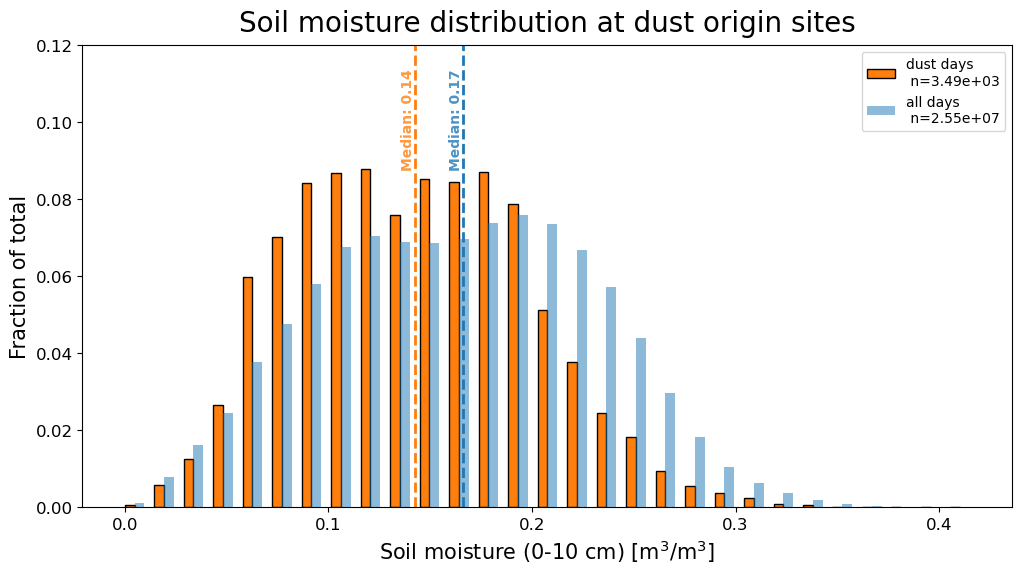

In [19]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust_days, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds_dust_sites["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Combined surface categories

In [20]:
combo_three_ds = xr.open_dataset("DATA/processed/7_surface_combo_dust_2026-06-22.nc")

In [22]:
#--- Apply dictionaries to get the category names

land_cover_dict = common_functions.get_land_cover_dict()
soil_order_dict = common_functions.get_soil_order_names_major()
texture_dict = common_functions.get_texture_dict()

combo_three_ds["combo_id"] = combo_three_ds["combo_id"].astype(int)

def decode_combo_id(combo_id):
    texture = combo_id // 1_000_000
    soil_order = (combo_id % 1_000_000) // 1_000
    surface_cover = combo_id % 1_000
    return texture, soil_order, surface_cover

def combo_id_to_label(combo_id):
    texture, soil, cover = decode_combo_id(combo_id)

    return (
        texture_dict.get(texture, f"Unknown({texture})"),
        soil_order_dict.get(soil, f"Unknown({soil})"),
        land_cover_dict.get(cover, f"Unknown({cover})")
    )

/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [23]:
combo_three_df = combo_three_ds[["combo_id", "dust_event_count"]].to_dataframe().reset_index()

#--- Remove the null row
combo_three_df = combo_three_df[combo_three_df["combo_id"] != -9223372036854775808]

grouped = combo_three_df.groupby("combo_id").agg(
    dust_event_count=("dust_event_count", "sum"),
    full_domain=("combo_id", "size")
)
grouped = grouped.sort_values("dust_event_count", ascending=False)

decoded = [
    (cid, *combo_id_to_label(cid), row.dust_event_count, row.full_domain)
    for cid, row in grouped.iterrows()
]

top_df = pd.DataFrame(
    decoded,
    columns=["combo_id", "texture", "soil_order", "surface_cover", "dust_events", "full_domain"]
)

top_df["dust_fraction"] = (
    top_df["dust_events"] / top_df["dust_events"].sum()
)

top_df["full_domain_fraction"] = (
    top_df["full_domain"] / top_df["full_domain"].sum()
)

top_df

,combo_id,texture,soil_order,surface_cover,dust_events,full_domain,dust_fraction,full_domain_fraction
0,11003016,Silty Clay,Entisols,Barren Lands,175.0,76.0,0.050143,0.000351
1,6003009,Loam,Entisols,Tropical/Sub-tropical Grassland,154.0,1382.0,0.044126,0.006391
2,6002007,Loam,Aridisols,Tropical/Sub-tropical Shrubland,139.0,11365.0,0.039828,0.052559
3,6003007,Loam,Entisols,Tropical/Sub-tropical Shrubland,123.0,10367.0,0.035244,0.047943
4,1002008,Sand,Aridisols,Temp/Sub-polar Shrubland,117.0,1793.0,0.033524,0.008292
...,...,...,...,...,...,...,...,...
835,6000014,Loam,Alfisols,Wetland,0.0,106.0,0.000000,0.000490
836,6000016,Loam,Alfisols,Barren Lands,0.0,18.0,0.000000,0.000083
837,6000018,Loam,Alfisols,Water,0.0,41.0,0.000000,0.000190
838,6000127,Loam,Alfisols,Unknown(127),0.0,53.0,0.000000,0.000245


In [24]:
top_full = top_df.sort_values("full_domain_fraction", ascending=False)
top_full

,combo_id,texture,soil_order,surface_cover,dust_events,full_domain,dust_fraction,full_domain_fraction
2,6002007,Loam,Aridisols,Tropical/Sub-tropical Shrubland,139.0,11365.0,0.039828,0.052559
6,3002008,Sandy Loam,Aridisols,Temp/Sub-polar Shrubland,112.0,11163.0,0.032092,0.051625
3,6003007,Loam,Entisols,Tropical/Sub-tropical Shrubland,123.0,10367.0,0.035244,0.047943
25,6002008,Loam,Aridisols,Temp/Sub-polar Shrubland,39.0,8361.0,0.011175,0.038666
64,6007008,Loam,Mollisols,Temp/Sub-polar Shrubland,14.0,8053.0,0.004011,0.037242
...,...,...,...,...,...,...,...,...
449,11000016,Silty Clay,Alfisols,Barren Lands,0.0,1.0,0.000000,0.000005
498,6014010,Loam,Shifting Sands,Temp/Sub-polar Grassland,0.0,1.0,0.000000,0.000005
452,12999015,Clay,Unknown(999),Cropland,0.0,1.0,0.000000,0.000005
812,6004019,Loam,Gelisols,Snow and Ice,0.0,1.0,0.000000,0.000005


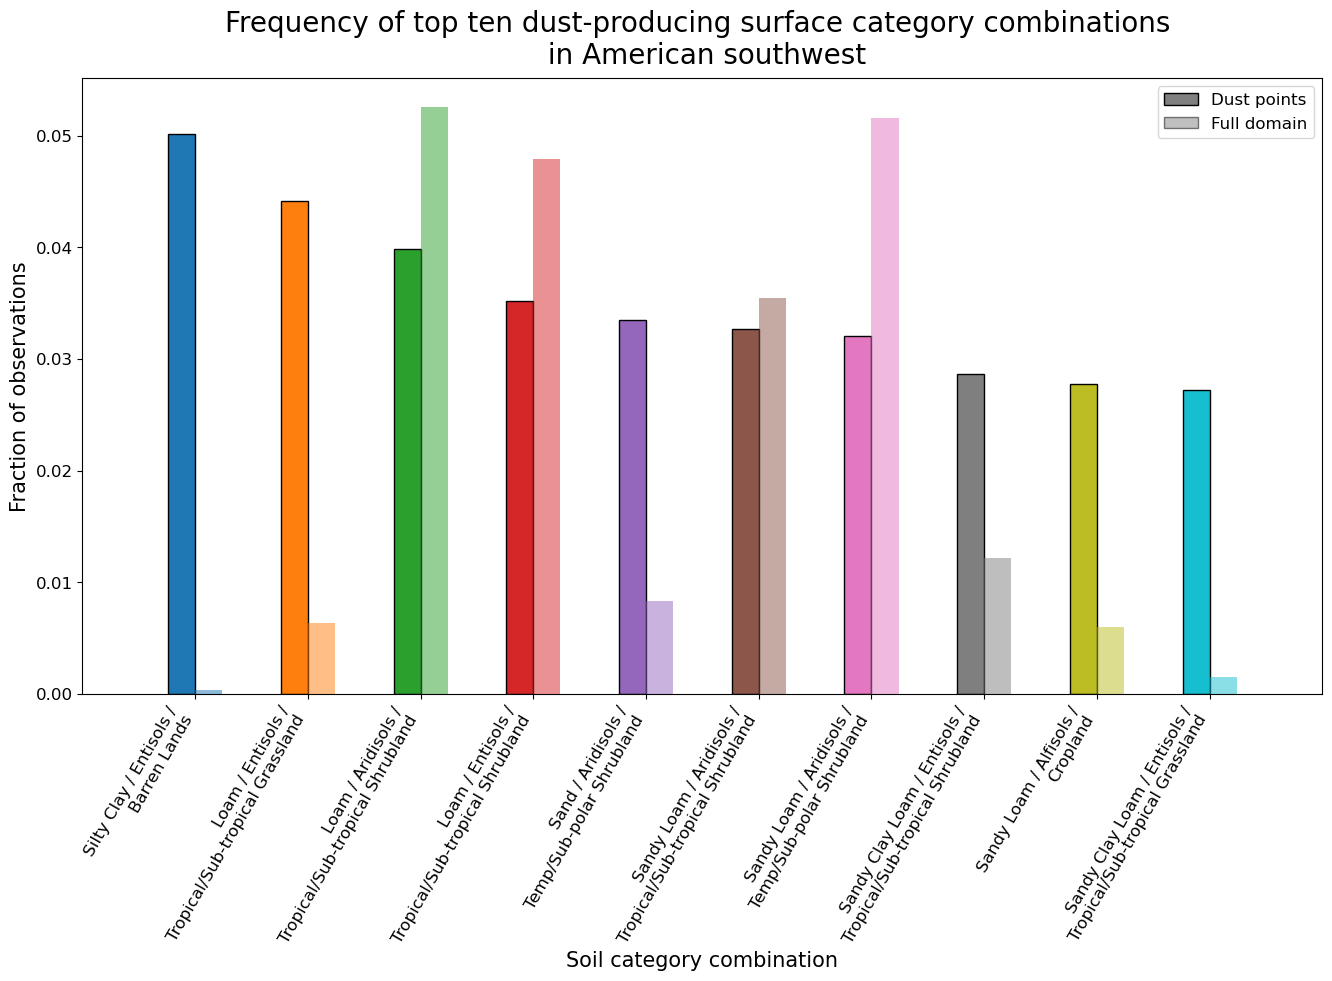

In [25]:
fig, ax = plt.subplots(figsize=(16, 8))

top_10_df = top_df[:10]
x = np.arange(len(top_10_df))
width = 0.24
x_labels = []

cmap = plt.cm.tab10
colors = cmap(np.linspace(0, 1, len(top_10_df)))

for i in np.arange(len(top_10_df)):
    ax.bar(
        x[i] - width/2,
        top_10_df['dust_fraction'][i],
        width=width,
        color=colors[i],
        edgecolor="black",
        label="Dust points" if i == 0 else None
    )
    ax.bar(
        x[i] + width/2,
        top_10_df['full_domain_fraction'][i],
        width=width,
        color=colors[i],
        alpha=0.5,
        edgecolor=None,
        label="Full domain" if i == 0 else None
    )
    x_labels.append(
        f"{top_10_df['texture'][i]} / "
        f"{top_10_df['soil_order'][i]} /\n"
        f"{top_10_df['surface_cover'][i]}"
    )

ax.set_xticks(x)
ax.tick_params(labelsize=12)
ax.set_xticklabels(x_labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlim(-1, len(top_10_df))
ax.set_xlabel("Soil category combination", fontsize=15)
ax.set_title(f"Frequency of top ten dust-producing surface category combinations \n in American southwest", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/6_combination_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()